C:\Users\muham\PycharmProjects\pythonProject\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 0.24.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\muham\PycharmProjects\pythonProject\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 0.24.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\muham\PycharmProjects\pythonProject\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVR from ver

Model A loaded successfully: MultiOutputRegressor(estimator=SVR(C=0.7500000000000001,
                                   epsilon=0.07900000000000001, gamma=0.1))
Model B loaded successfully: MultiOutputRegressor(estimator=SVR(C=3, epsilon=0.005, gamma=0.005))
Selected 20 images for evaluation.

[1/20] Processing: image02720.jpg

[2/20] Processing: image00374.jpg

[3/20] Processing: image00077.jpg

[4/20] Processing: image03255.jpg

[5/20] Processing: image00948.jpg

[6/20] Processing: image00840.jpg

[7/20] Processing: image00771.jpg

[8/20] Processing: image00473.jpg
No face landmarks for Model A.
No face landmarks for Model B.

[9/20] Processing: image03233.jpg

[10/20] Processing: image00343.jpg

[11/20] Processing: image02870.jpg

[12/20] Processing: image03250.jpg

[13/20] Processing: image03932.jpg

[14/20] Processing: image02219.jpg

[15/20] Processing: image00296.jpg

[16/20] Processing: image02453.jpg

[17/20] Processing: image01646.jpg

[18/20] Processing: image00095.jpg

[19

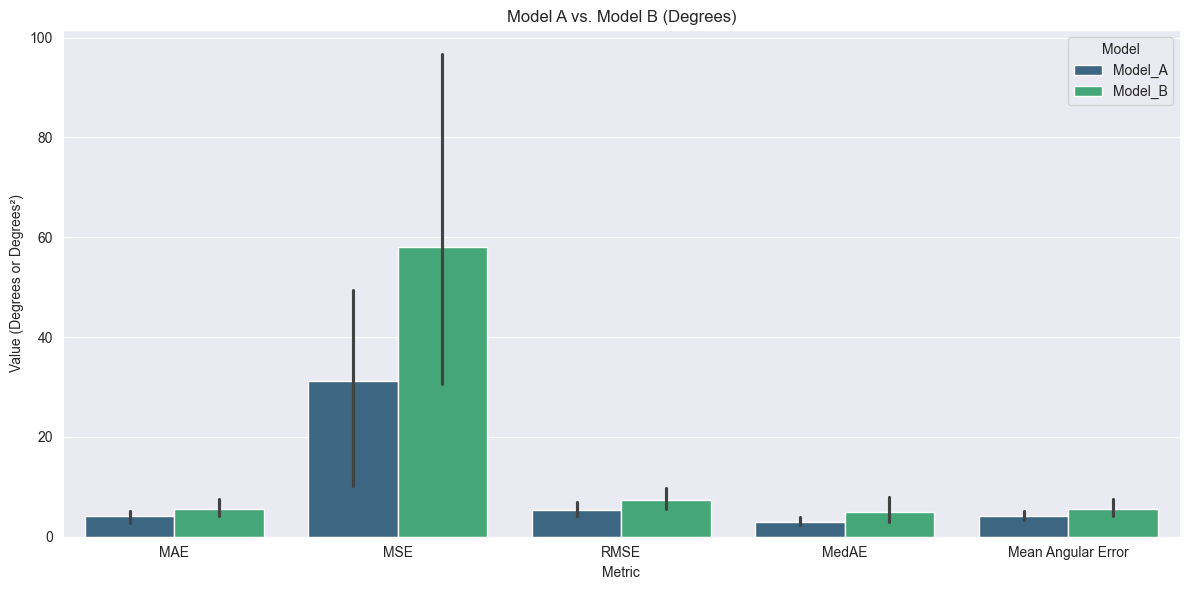

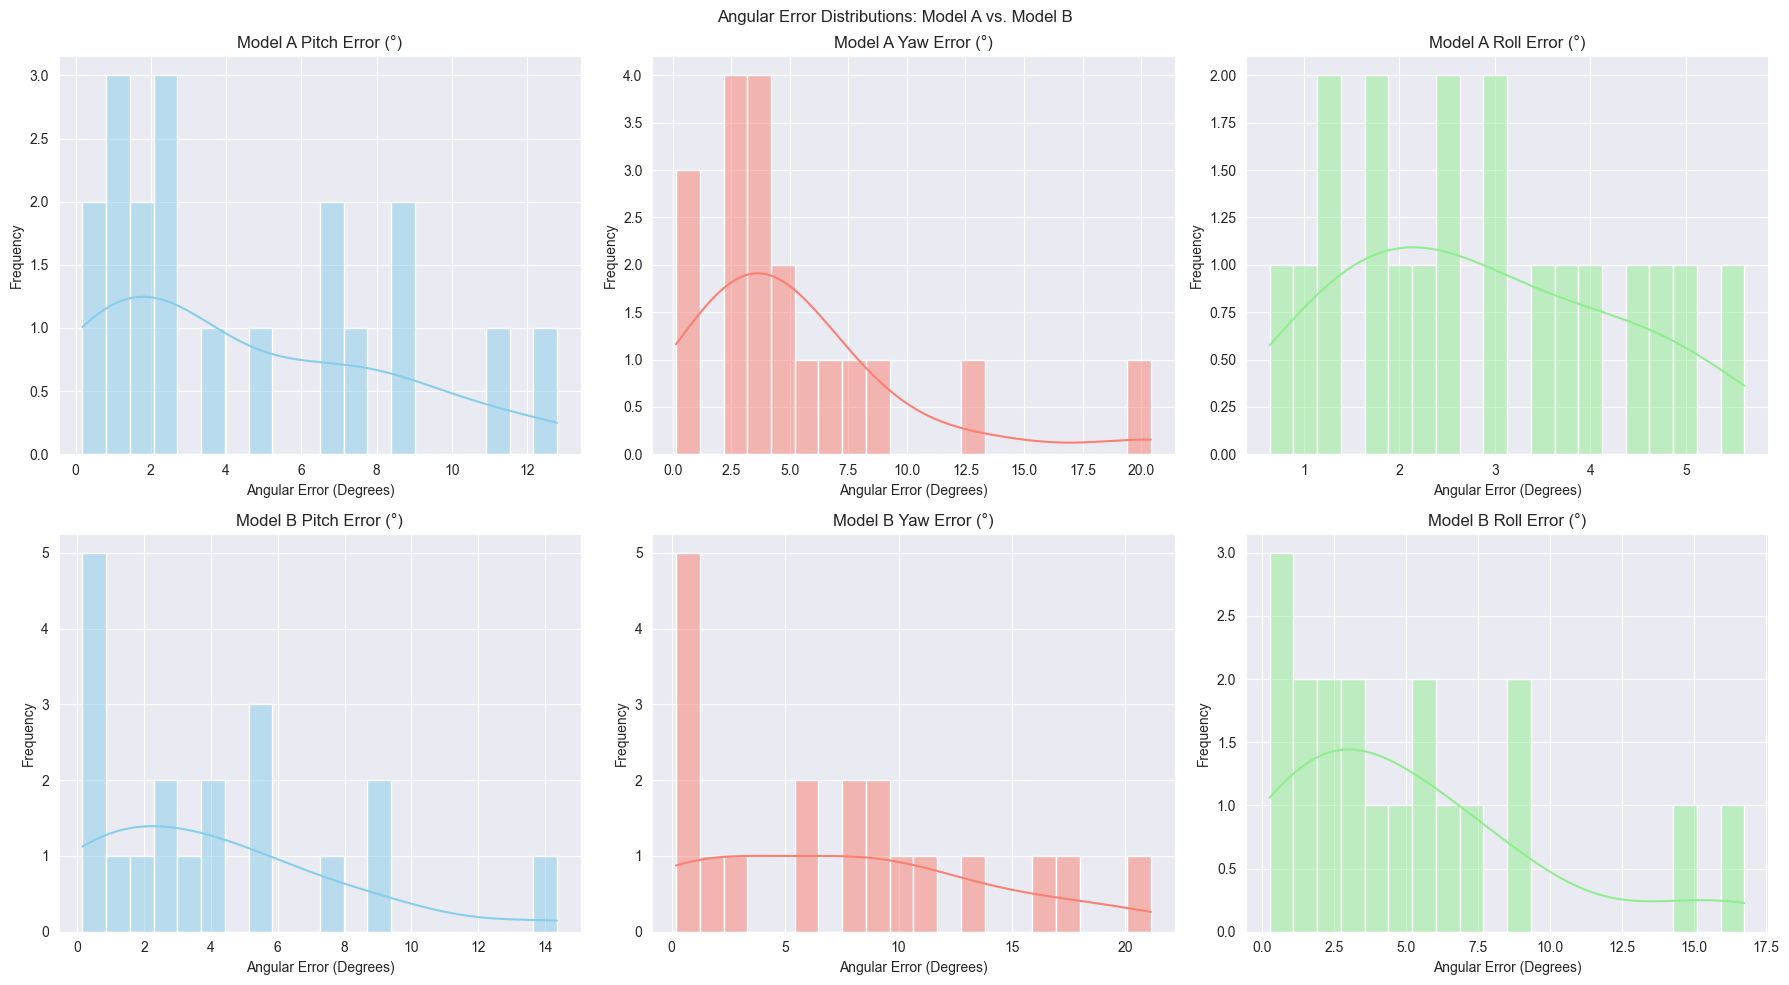


=== Done! ===


In [2]:
import os
import glob
import random
import pickle
import numpy as np
import pandas as pd
import scipy.io as sio
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error
)

#######################################################################
# 1. Setup and Configuration
#######################################################################

# Paths to models
MODEL_A_PATH = "model.pkl"      # 7-landmark model
MODEL_B_PATH = "SVR_model.sav"          # 468-landmark model

# Dataset directory
DATASET_DIR = r"C:\Users\muham\PycharmProjects\pythonProject\face_pose\AFLW2000"

# Number of images to evaluate
NUM_IMAGES = 20

# Random seed (for reproducibility)
random.seed(42)

#######################################################################
# 2. Load Both Models
#######################################################################
with open(MODEL_A_PATH, 'rb') as fA:
    modelA = pickle.load(fA)
print("Model A loaded successfully:", modelA)

with open(MODEL_B_PATH, 'rb') as fB:
    modelB = pickle.load(fB)
print("Model B loaded successfully:", modelB)

#######################################################################
# 3. Initialize Mediapipe
#######################################################################
mp_face_mesh = mp.solutions.face_mesh
face_mesh_static = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.5
)

# For Model A (7 Key Landmarks):
LANDMARKS_A = {
    'NOSE': 1,
    'FOREHEAD': 10,
    'LEFT_EYE': 33,
    'MOUTH_LEFT': 61,
    'CHIN': 199,
    'RIGHT_EYE': 263,
    'MOUTH_RIGHT': 291
}

# Columns for Model A
COLS_A = []
for pos in ['nose_', 'forehead_', 'left_eye_', 'mouth_left_', 'chin_', 'right_eye_', 'mouth_right_']:
    for dim in ('x', 'y'):
        COLS_A.append(pos + dim)

#######################################################################
# 4. Feature Extraction for Each Model
#######################################################################

def extract_features_modelA(img_rgb, face_mesh_processor):
    """
    Extract 7 specific MediaPipe landmarks for Model A, then normalize.
    Returns a (1,14)-length array: x,y for each of 7 landmarks.
    """
    result = face_mesh_processor.process(img_rgb)
    if not result.multi_face_landmarks:
        return None

    face_landmarks = result.multi_face_landmarks[0]
    # Collect 14 points (x,y) from 7 key landmarks
    features = []
    for idx_name in LANDMARKS_A.values():
        lm = face_landmarks.landmark[idx_name]
        features.append(lm.x)
        features.append(lm.y)

    # Convert to DataFrame for normalization
    df = pd.DataFrame([features], columns=COLS_A)
    df_normalized = normalize_modelA(df)
    return df_normalized.values  # shape (1,14)

def normalize_modelA(poses_df):
    """
    Normalization used by Model A:
    1) Center around nose
    2) Scale by (mouth_right - left_eye) for x & y
    """
    df = poses_df.copy()
    for dim in ['x', 'y']:
        # Center around nose
        for feat in ['forehead_'+dim, 'nose_'+dim, 'mouth_left_'+dim,
                     'mouth_right_'+dim, 'left_eye_'+dim, 'chin_'+dim, 'right_eye_'+dim]:
            df[feat] = poses_df[feat] - poses_df['nose_'+dim]

        # Scale
        diff = df['mouth_right_'+dim] - df['left_eye_'+dim]
        for feat in ['forehead_'+dim, 'nose_'+dim, 'mouth_left_'+dim,
                     'mouth_right_'+dim, 'left_eye_'+dim, 'chin_'+dim, 'right_eye_'+dim]:
            df[feat] = df[feat] / diff
    return df

def extract_features_modelB(img_rgb, face_mesh_processor, width, height):
    """
    Extract all 468 MediaPipe landmarks for Model B, then
    apply the "preprocess" (center at nose, scale by max).
    Returns shape (1,936).
    """
    result = face_mesh_processor.process(img_rgb)
    if not result.multi_face_landmarks:
        return None

    face = result.multi_face_landmarks[0]
    x_val = np.array([lm.x * width for lm in face.landmark])
    y_val = np.array([lm.y * height for lm in face.landmark])

    # Center around the nose (landmark #1)
    x_center = x_val[1]
    y_center = y_val[1]
    x_val -= x_center
    y_val -= y_center

    # Normalize by max absolute val
    x_max = np.max(np.abs(x_val)) if np.max(np.abs(x_val)) != 0 else 1
    y_max = np.max(np.abs(y_val)) if np.max(np.abs(y_val)) != 0 else 1
    x_val /= x_max
    y_val /= y_max

    return np.concatenate([x_val, y_val]).reshape(1, -1)  # shape (1, 936)

#######################################################################
# 5. Data Loading & Selection
#######################################################################
image_paths = glob.glob(os.path.join(DATASET_DIR, "*.jpg"))
if len(image_paths) < NUM_IMAGES:
    print(f"Warning: Found only {len(image_paths)} images. Using all.")
    selected_images = image_paths
else:
    selected_images = random.sample(image_paths, NUM_IMAGES)

print(f"Selected {len(selected_images)} images for evaluation.")

#######################################################################
# 6. Evaluate Both Models on the Same Images
#######################################################################
results = []  # Will store dicts of [image_path, pitchA, yawA, rollA, pitchB, yawB, rollB, pitchGT, yawGT, rollGT]

for i, img_path in enumerate(selected_images):
    print(f"\n[{i+1}/{len(selected_images)}] Processing: {os.path.basename(img_path)}")

    # Load image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print("Failed to load image. Skipping.")
        continue

    # Convert to RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_bgr.shape

    # Ground Truth
    mat_path = img_path.replace(".jpg", ".mat")
    if os.path.exists(mat_path):
        mat_data = sio.loadmat(mat_path)
        # 'Pose_Para'[0][:3] -> [pitch, yaw, roll] in radians
        if 'Pose_Para' in mat_data:
            pitchGT, yawGT, rollGT = mat_data['Pose_Para'][0][:3]
        else:
            pitchGT, yawGT, rollGT = None, None, None
    else:
        pitchGT, yawGT, rollGT = None, None, None

    # ========================== Model A Extraction ==========================
    featA = extract_features_modelA(img_rgb, face_mesh_static)
    pitchA, yawA, rollA = None, None, None
    if featA is not None:
        try:
            pitchA, yawA, rollA = modelA.predict(featA)[0]
        except Exception as e:
            print(f"Model A Prediction Error: {e}")
            pitchA, yawA, rollA = None, None, None
    else:
        print("No face landmarks for Model A.")

    # ========================== Model B Extraction ==========================
    featB = extract_features_modelB(img_rgb, face_mesh_static, w, h)
    pitchB, yawB, rollB = None, None, None
    if featB is not None:
        try:
            pitchB, yawB, rollB = modelB.predict(featB)[0]
        except Exception as e:
            print(f"Model B Prediction Error: {e}")
            pitchB, yawB, rollB = None, None, None
    else:
        print("No face landmarks for Model B.")

    # Collect results
    results.append({
        'Image_Path': img_path,
        # Predictions
        'PitchA': pitchA,
        'YawA': yawA,
        'RollA': rollA,
        'PitchB': pitchB,
        'YawB': yawB,
        'RollB': rollB,
        # Ground Truth
        'Pitch_GT': pitchGT,
        'Yaw_GT': yawGT,
        'Roll_GT': rollGT
    })

df_results = pd.DataFrame(results)
print("\n--- Combined Results ---")
print(df_results)

#######################################################################
# 7. Filter Valid Rows (Where Both Models & GT Are Present)
#######################################################################
df_valid = df_results.dropna(subset=['PitchA', 'YawA', 'RollA',
                                     'PitchB', 'YawB', 'RollB',
                                     'Pitch_GT', 'Yaw_GT', 'Roll_GT']).reset_index(drop=True)

if df_valid.empty:
    print("No valid samples with both models' predictions and ground truth. Exiting.")
    exit()

#######################################################################
# 8. Define Metric Functions & Evaluate
#######################################################################
def angular_difference(pred, gt):
    """Computes minimal angular difference considering 2*pi periodicity."""
    diff = np.abs(pred - gt)
    return np.minimum(diff, 2 * np.pi - diff)

def compute_metrics_in_degrees(y_pred, y_true):
    """
    Given arrays of predictions and ground truths in *radians*,
    returns a dict of metrics in *degrees*.
    """
    mae_rad = mean_absolute_error(y_true, y_pred)
    mse_rad = mean_squared_error(y_true, y_pred)
    rmse_rad = np.sqrt(mse_rad)
    medae_rad = median_absolute_error(y_true, y_pred)

    # For "Mean Angular Error", we use the minimal difference
    # but in many cases, it's similar to mae if angles are small.
    # We'll compute a per-sample minimal difference first:
    angular_errors = angular_difference(y_pred, y_true)
    mean_ang_rad = np.mean(angular_errors)

    # Convert everything to degrees
    deg_factor = 180.0 / np.pi
    mae_deg = mae_rad * deg_factor
    mse_deg = mse_rad * (deg_factor**2)
    rmse_deg = rmse_rad * deg_factor
    medae_deg = medae_rad * deg_factor
    mean_ang_deg = mean_ang_rad * deg_factor

    return {
        'MAE': mae_deg,
        'MSE': mse_deg,
        'RMSE': rmse_deg,
        'MedAE': medae_deg,
        'Mean Angular Error': mean_ang_deg
    }

def evaluate_model(df, prefix='A'):
    """
    Evaluate model given a prefix ('A' or 'B'):
      - df['PitchA'], df['Pitch_GT'] in radians, etc.
    Returns a dict of metric dicts: { 'Pitch': {...}, 'Yaw': {...}, 'Roll': {...} }
    """
    metrics_dict = {}
    # Pitch
    metrics_dict['Pitch'] = compute_metrics_in_degrees(
        df[f'Pitch{prefix}'].values, df['Pitch_GT'].values
    )
    # Yaw
    metrics_dict['Yaw'] = compute_metrics_in_degrees(
        df[f'Yaw{prefix}'].values, df['Yaw_GT'].values
    )
    # Roll
    metrics_dict['Roll'] = compute_metrics_in_degrees(
        df[f'Roll{prefix}'].values, df['Roll_GT'].values
    )
    return metrics_dict

#######################################################################
# 9. Evaluate Model A vs. Model B
#######################################################################
metricsA = evaluate_model(df_valid, prefix='A')
metricsB = evaluate_model(df_valid, prefix='B')

# Prepare a comparison DataFrame in degrees
# Let's define a function to reshape the results:
def reshape_metrics(metrics_dict, model_name):
    """
    metrics_dict like:
    {
      'Pitch': {'MAE': val, 'MSE': val, ...},
      'Yaw': {...},
      'Roll': {...}
    }
    Convert to a DataFrame with columns ['Metric', 'Angle', 'Value', 'Model']
    """
    records = []
    for angle, angle_dict in metrics_dict.items():
        for metric_name, val in angle_dict.items():
            records.append({
                'Angle': angle,
                'Metric': metric_name,
                'Value': val,
                'Model': model_name
            })
    return pd.DataFrame(records)

dfA = reshape_metrics(metricsA, 'Model_A')
dfB = reshape_metrics(metricsB, 'Model_B')

df_compare = pd.concat([dfA, dfB], ignore_index=True)
print("\n--- Side-by-Side Metrics (Degrees) ---")
print(df_compare)

#######################################################################
# 10. Visualization of Side-by-Side Bar Charts
#######################################################################
plt.figure(figsize=(12, 6))
sns.barplot(data=df_compare, x='Metric', y='Value', hue='Model', palette='viridis')
plt.title('Model A vs. Model B (Degrees)')
plt.ylabel('Value (Degrees or Degrees²)')
plt.xlabel('Metric')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

#######################################################################
# 11. (Optional) Detailed Error Histograms Per Model
#######################################################################
def get_angular_errors_in_degrees(df, prefix='A'):
    """
    Returns 3 arrays of per-sample angular errors in degrees
    for Pitch, Yaw, Roll.
    """
    pitch_err = angular_difference(df[f'Pitch{prefix}'], df['Pitch_GT']) * (180.0/np.pi)
    yaw_err   = angular_difference(df[f'Yaw{prefix}'],   df['Yaw_GT'])   * (180.0/np.pi)
    roll_err  = angular_difference(df[f'Roll{prefix}'],  df['Roll_GT'])  * (180.0/np.pi)
    return pitch_err, yaw_err, roll_err

pitch_errA, yaw_errA, roll_errA = get_angular_errors_in_degrees(df_valid, 'A')
pitch_errB, yaw_errB, roll_errB = get_angular_errors_in_degrees(df_valid, 'B')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Model A Histograms
sns.histplot(pitch_errA, bins=20, kde=True, ax=axes[0][0], color='skyblue')
axes[0][0].set_title('Model A Pitch Error (°)')
sns.histplot(yaw_errA, bins=20, kde=True, ax=axes[0][1], color='salmon')
axes[0][1].set_title('Model A Yaw Error (°)')
sns.histplot(roll_errA, bins=20, kde=True, ax=axes[0][2], color='lightgreen')
axes[0][2].set_title('Model A Roll Error (°)')

# Model B Histograms
sns.histplot(pitch_errB, bins=20, kde=True, ax=axes[1][0], color='skyblue')
axes[1][0].set_title('Model B Pitch Error (°)')
sns.histplot(yaw_errB, bins=20, kde=True, ax=axes[1][1], color='salmon')
axes[1][1].set_title('Model B Yaw Error (°)')
sns.histplot(roll_errB, bins=20, kde=True, ax=axes[1][2], color='lightgreen')
axes[1][2].set_title('Model B Roll Error (°)')

for row in range(2):
    for col in range(3):
        axes[row][col].set_xlabel('Angular Error (Degrees)')
        axes[row][col].set_ylabel('Frequency')
        axes[row][col].grid(True)

plt.suptitle("Angular Error Distributions: Model A vs. Model B")
plt.tight_layout()
plt.show()

print("\n=== Done! ===")


Image_Path    C:\Users\muham\PycharmProjects\pythonProject\f...
PitchA                                                -0.166931
YawA                                                  -0.159496
RollA                                                  0.015152
PitchB                                                -0.195391
YawB                                                  -0.125416
RollB                                                 -0.042427
Pitch_GT                                              -0.187202
Yaw_GT                                                -0.075385
Roll_GT                                               -0.008907
Name: 4, dtype: object


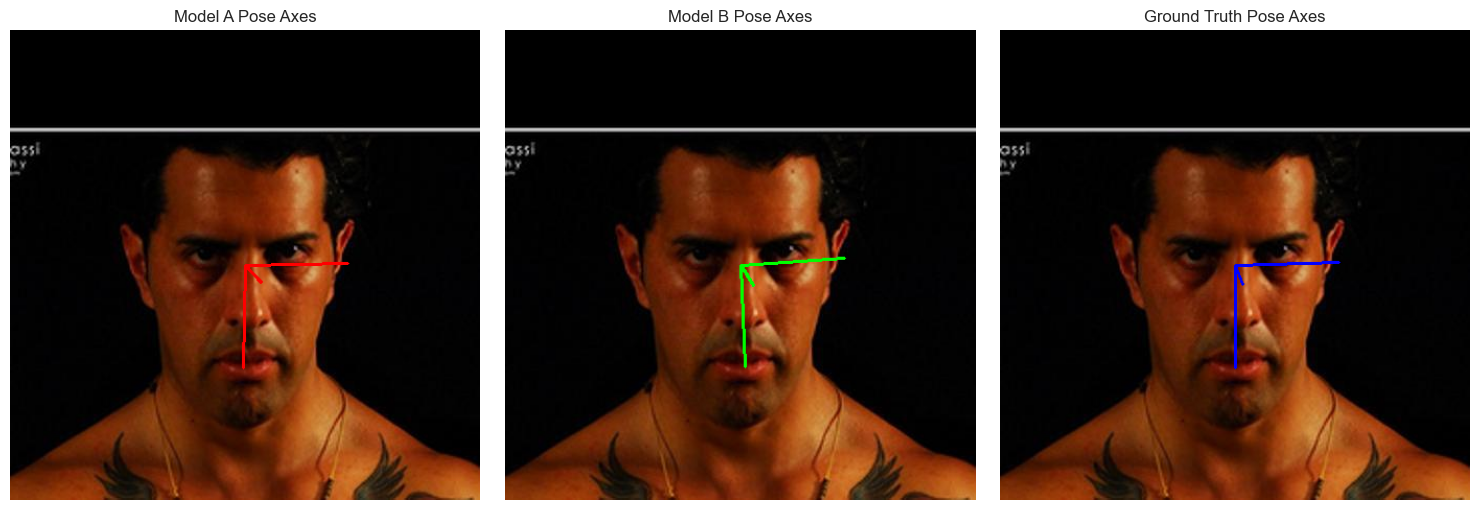

In [3]:
# Let's say df_valid is your final DataFrame with valid predictions & ground truth
sample_idx = 4  # This is the 5th sample in 0-based indexing

row = df_valid.iloc[sample_idx]
print(row)
import cv2
import matplotlib.pyplot as plt

img_path = row['Image_Path']
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    print("Error loading image.")
else:
    # Convert to RGB for plotting
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
def draw_head_pose(img_rgb, pitch, yaw, roll, origin_x, origin_y, size=100, color=(0, 0, 255), thickness=2):
    """
    Draws the pitch, yaw, roll axes on the image.
    color is in RGB format, thickness is line thickness.
    """
    import math
    # Invert yaw for consistency with typical definitions
    yaw = -yaw

    x1 = size * (math.cos(yaw) * math.cos(roll)) + origin_x
    y1 = size * (math.cos(pitch) * math.sin(roll) + math.cos(roll) * math.sin(pitch) * math.sin(yaw)) + origin_y

    x2 = size * (-math.cos(yaw) * math.sin(roll)) + origin_x
    y2 = size * (math.cos(pitch) * math.cos(roll) - math.sin(pitch) * math.sin(yaw) * math.sin(roll)) + origin_y

    x3 = size * (math.sin(yaw)) + origin_x
    y3 = size * (-math.cos(yaw) * math.sin(pitch)) + origin_y

    # Draw lines
    cv2.line(img_rgb, (int(origin_x), int(origin_y)), (int(x1), int(y1)), color, thickness)
    cv2.line(img_rgb, (int(origin_x), int(origin_y)), (int(x2), int(y2)), color, thickness)
    cv2.line(img_rgb, (int(origin_x), int(origin_y)), (int(x3), int(y3)), color, thickness)

    return img_rgb
height, width = img_rgb.shape[:2]
origin_x = width // 2
origin_y = height // 2
# Create copies for each set of axes
img_predA = img_rgb.copy()
img_predB = img_rgb.copy()
img_gt    = img_rgb.copy()

# Retrieve angles (assuming they're in row and are radians)
pitchA, yawA, rollA = row['PitchA'], row['YawA'], row['RollA']
pitchB, yawB, rollB = row['PitchB'], row['YawB'], row['RollB']
pitchGT, yawGT, rollGT = row['Pitch_GT'], row['Yaw_GT'], row['Roll_GT']

# Use the image center as origin (or your nose location)
h, w = img_rgb.shape[:2]
center_x, center_y = w // 2, h // 2

# Draw Model A
if pd.notnull(pitchA) and pd.notnull(yawA) and pd.notnull(rollA):
    img_predA = draw_head_pose(img_predA, pitchA, yawA, rollA,
                               center_x, center_y,
                               size=100, color=(255, 0, 0), thickness=2)
# Draw Model B
if pd.notnull(pitchB) and pd.notnull(yawB) and pd.notnull(rollB):
    img_predB = draw_head_pose(img_predB, pitchB, yawB, rollB,
                               center_x, center_y,
                               size=100, color=(0, 255, 0), thickness=2)
# Draw Ground Truth
if pd.notnull(pitchGT) and pd.notnull(yawGT) and pd.notnull(rollGT):
    img_gt = draw_head_pose(img_gt, pitchGT, yawGT, rollGT,
                            center_x, center_y,
                            size=100, color=(0, 0, 255), thickness=2)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.imshow(img_predA)
plt.title("Model A Pose Axes")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_predB)
plt.title("Model B Pose Axes")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_gt)
plt.title("Ground Truth Pose Axes")
plt.axis('off')

plt.tight_layout()
plt.show()
